## 1. Introduction (25%)
本报告研究的金融问题是在风险中性定价框架下，对基于同一标的股票的欧式看涨期权和二元看涨期权进行估值。假设标的股票价格服从几何布朗运动（Geometric Brownian Motion, GBM），在风险中性测度下，期权的当前公平价格等于到期 payoff 的贴现风险中性期望。欧式看涨期权的 payoff 为 $\max(S_T-K,0)$，二元看涨期权的 payoff 为 $\mathbf{1}_{S_T>K}$。两类期权都依赖到期股票价格 $S_T$，但二元期权的 payoff 是不连续的阶梯函数，因此其价格表现和数值稳定性可能不同于普通欧式看涨期权。

蒙特卡洛方法适合用于本题，因为它可以通过大量模拟路径近似风险中性期望，并可直接处理不同形式的 payoff。本报告使用三种方法模拟标的股票价格：GBM closed-form path simulation、Euler-Maruyama scheme 和 Milstein scheme。其中，GBM closed-form simulation 使用股价过程的解析解生成 exact GBM path 或 exact terminal value；Euler-Maruyama 和 Milstein 则是在离散时间网格上对 SDE 进行数值近似。Milstein 方法相对于 Euler-Maruyama 多包含一个二阶修正项，因此理论上对路径离散有更高的强收敛阶。

本报告采用的数值流程如下：首先设定基准参数 $S_0, K, r, \sigma, T$，并将到期时间划分为 $M=252$ 个交易日时间步；然后生成 $N=100000$ 条随机路径，分别使用三种股价模拟方法得到到期价格 $S_T$；接着根据 $S_T$ 计算欧式看涨和二元看涨 payoff，并用 $e^{-rT}$ 贴现 payoff 的样本均值作为期权价格估计；最后计算标准误差，用于衡量蒙特卡洛估计的不确定性。

除基准定价外，本报告还改变 $S_0, K, r, \sigma, T$ 等输入参数，分析不同市场条件对期权价格的影响。报告进一步实现对偶变量法（Antithetic Variates），用 $\phi$ 和 $-\phi$ 构造负相关路径，检验其对蒙特卡洛标准误差的降低效果。为了回应题目中对 results、error analysis 和 comparisons 的要求，本报告比较三种模拟方法的价格、标准误差和敏感性趋势，并使用 Black-Scholes 欧式看涨公式及 cash-or-nothing binary call 解析公式作为 analytical benchmark 计算绝对误差。这里的解析公式仅用于误差分析，不作为题目要求的三种股价模拟方法之一。

本报告的实现风格遵循课程资料：股价模拟采用课程中的 Euler/Milstein 离散形式，对偶变量方法参考 JA26T5 讲义，路径可视化、标准误差和方差缩减比较均与课程示例保持一致。

---

## 2. 模型与方法（来自课程与考试文档）
### 2.1 几何布朗运动 GBM
风险中性下 SDE：
$$dS_t = r S_t dt + \sigma S_t dW_t$$

### 2.2 GBM 闭式解（指数形式）
$$S_T = S_0 \exp\left\{\left(r-\frac12\sigma^2\right)T + \sigma\phi\sqrt{T}\right\},\quad \phi\sim N(0,1)$$

### 2.3 欧拉法（课程线性形式，无指数）
$$S_{t+\delta t} = S_t\left(1 + r\delta t + \sigma\phi\sqrt{\delta t}\right)$$

### 2.4 米尔斯坦法（课程线性形式）
$$S_{t+\delta t} = S_t\left(1 + r\delta t + \sigma\phi\sqrt{\delta t} + \frac12\sigma^2(\phi^2-1)\delta t\right)$$

### 2.5 期权收益
欧式看涨：
$$\text{Payoff}_{\text{European}} = \max(S_T-K,0)$$

二元看涨：
$$
\text{Payoff}_{\text{Binary}} = 
\begin{cases}
1 & S_T>K \\
0 & \text{其他}
\end{cases}
$$

### 2.6 蒙特卡洛定价与标准误差
价格：
$$\text{Price} = e^{-rT}\cdot\frac1N\sum \text{Payoff}_i$$

标准误差（课程必写；由于价格估计量是贴现 payoff 的样本均值，标准误差也需要乘以贴现因子）：
$$\text{SE} = e^{-rT}\cdot\frac{\text{std}(\text{Payoff})}{\sqrt{N}}$$

### 2.7 对偶变量法（来自 JA26T5 讲义）
课程讲义和 `9_montecarlo.ipynb` 中通常将 $n$ 或 `n_paths` 作为 antithetic pair 数量，因此实际路径计算数为 $2n$。为了让本报告中的普通 MC 和 AV 使用相同的总路径预算，本报告改用总路径数 $N$ 表示计算预算，并令 antithetic pair 数量为 $N/2$。

使用 $\phi$ 与 $-\phi$ 构造负相关路径：
$$\hat{V}_A = e^{-rT}\cdot\frac{2}{N}\sum_{i=1}^{N/2} \frac{f(S_T(\phi_i)) + f(S_T(-\phi_i))}{2}$$

也即对 $N/2$ 个 pair average 样本求平均。标准误差按 $N/2$ 个 pair average 样本计算，即对 $\frac{f(S_T(\phi_i))+f(S_T(-\phi_i))}{2}$ 的样本均值计算标准误差。

方差缩减来自负协方差：
$$\text{Var}\left(\frac{X+Y}{2}\right) = \frac12\sigma^2 + \frac12\text{Cov}(X,Y),\quad \text{Cov}<0$$

---

## 3. 基础参数
- $S_0=100,\ K=100,\ r=0.05,\ \sigma=0.2,\ T=1$
- 普通蒙特卡洛路径数 $N=100000$
- 对偶变量法固定总路径数为 $N=100000$，因此使用 $N/2=50000$ 对 antithetic pairs，即 $50000$ 条正向路径和 $50000$ 条负向路径
- 时间步数 $M=252$（与课程 notebook 中按交易日离散的设置一致）
- $\delta t = T/M$

---

### 3.1 初始参数与依赖

In [1]:
%pip install numpy
%pip install matplotlib
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 基础参数（与课程一致，M=252）
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1
N = 100000
M = 252
dt = T / M

# 4. 标的股价模拟与初始参数定价结果

本节按照课程 `9_montecarlo.ipynb` 的流程，先模拟 underlying stock price paths，展示路径 DataFrame 并画出前100条路径；然后使用模拟得到的终值 $S_T$ 计算欧式看涨期权和二元看涨期权价格。初始参数为 $S_0=100, K=100, r=0.05, \sigma=0.2, T=1$。

In [3]:
# 第4节路径模拟设置：对齐9_montecarlo.ipynb中的示例
baseline_n_paths = N
baseline_n_steps = M
baseline_n_plot_paths = 100
baseline_dt = T / baseline_n_steps
baseline_time_grid = np.linspace(0, T, baseline_n_steps + 1)

# 三种方法使用同一组随机数，便于公平比较路径差异
baseline_random_normals = np.random.normal(0, 1, (baseline_n_paths, baseline_n_steps))

def simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps, random_normals=None):
    dt_local = T / n_steps
    time_grid = np.linspace(0, T, n_steps + 1)
    if random_normals is None:
        random_normals = np.random.normal(0, 1, (n_paths, n_steps))
    W = np.zeros((n_paths, n_steps + 1))
    W[:, 1:] = np.cumsum(np.sqrt(dt_local) * random_normals, axis=1)
    paths = S0 * np.exp((r - 0.5 * sigma**2) * time_grid.reshape(1, -1) + sigma * W)
    return paths

def simulate_euler_paths(S0, r, sigma, T, n_paths, n_steps, random_normals=None):
    dt_local = T / n_steps
    if random_normals is None:
        random_normals = np.random.normal(0, 1, (n_paths, n_steps))
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0
    for t in range(1, n_steps + 1):
        z = random_normals[:, t - 1]
        paths[:, t] = paths[:, t - 1] * (1 + r * dt_local + sigma * z * np.sqrt(dt_local))
    return paths

def simulate_milstein_paths(S0, r, sigma, T, n_paths, n_steps, random_normals=None):
    dt_local = T / n_steps
    if random_normals is None:
        random_normals = np.random.normal(0, 1, (n_paths, n_steps))
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0
    for t in range(1, n_steps + 1):
        z = random_normals[:, t - 1]
        milstein_term = 0.5 * sigma**2 * (z**2 - 1) * dt_local
        paths[:, t] = paths[:, t - 1] * (1 + r * dt_local + sigma * z * np.sqrt(dt_local) + milstein_term)
    return paths

def plot_simulated_paths(paths, title):
    plt.figure(figsize=(9, 5))
    plt.plot(baseline_time_grid, paths[:baseline_n_plot_paths].T, linewidth=0.8, alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Stock price")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

def calculate_payoff(S_T, option_type="european", *, strike):
    if option_type == "european":
        return np.maximum(S_T - strike, 0)
    elif option_type == "binary":
        return np.where(S_T > strike, 1, 0)
    else:
        raise ValueError("option_type 仅支持 european 或 binary")

def monte_carlo_pricing(S_T, option_type="european", *, strike, rate, maturity):
    payoff = calculate_payoff(S_T, option_type, strike=strike)
    discount = np.exp(-rate * maturity)
    price = discount * np.mean(payoff)
    se = discount * np.std(payoff) / np.sqrt(np.size(payoff))
    return price, se

def price_options_from_terminal_stock(S_T):
    euro_price, euro_se = monte_carlo_pricing(S_T, "european", strike=K, rate=r, maturity=T)
    binary_price, binary_se = monte_carlo_pricing(S_T, "binary", strike=K, rate=r, maturity=T)
    return euro_price, euro_se, binary_price, binary_se

def make_single_method_pricing_table(method_name, euro_price, euro_se, binary_price, binary_se):
    table = pd.DataFrame(
        [[method_name, euro_price, euro_se, binary_price, binary_se]],
        columns=["方法", "欧式价格", "欧式SE", "二元价格", "二元SE"],
    )
    return table.round({"欧式价格": 4, "欧式SE": 6, "二元价格": 4, "二元SE": 6})

## 4.1 GBM closed-form solution 路径模拟

GBM closed-form solution 指股价过程的解析解。这里在每个时间点用累计 Brownian motion 构造 exact GBM path。

,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.962222,101.757392,104.252767,105.805725,105.516242,107.351422,106.472279,106.230762,104.320897,...,108.873306,107.221919,107.324049,108.300981,107.065017,108.665090,110.018903,110.182544,110.289034,110.764000
1,100.0,100.052229,100.365609,98.774454,97.381418,96.977424,97.532418,98.525019,98.036768,98.786929,...,76.188686,78.010650,77.606531,76.906100,76.161737,74.613014,76.089496,76.802939,77.208130,77.526182
2,100.0,100.243158,101.588432,100.291208,100.472869,102.531791,103.721267,101.576454,99.377561,97.220656,...,83.948017,84.314508,82.763058,82.319086,83.387696,84.129637,83.806757,82.661451,84.822912,84.868750
3,100.0,100.934839,99.345357,98.038945,99.254582,98.221817,97.424348,97.768367,97.681105,98.177354,...,74.444388,76.153189,76.206773,75.445346,75.583000,76.382201,75.733833,76.047599,74.506614,74.674862
4,100.0,100.139725,101.503929,100.896299,101.052506,100.618098,99.518484,100.053985,99.994626,100.001501,...,90.790921,90.899893,92.152310,93.099893,95.115863,95.780181,96.036043,96.668940,95.979289,98.165838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,100.0,99.475131,98.317516,99.388009,101.384107,101.781329,102.448099,101.190215,99.733871,98.668291,...,115.856591,116.674370,113.717061,110.937344,110.894189,111.203060,109.987336,106.123011,105.868690,103.935625
99996,100.0,100.028414,101.620966,104.005437,102.183958,99.842901,97.727663,98.643630,99.801071,100.706598,...,95.516693,96.002605,95.463926,96.162379,93.594456,94.217188,97.386941,94.360880,94.792076,95.647463
99997,100.0,100.311781,100.359775,100.061352,99.803411,100.941214,101.588899,101.976696,102.190621,101.241239,...,100.004150,99.090521,97.637904,97.575480,98.067910,98.782009,99.744145,101.486894,100.805495,102.606185
99998,100.0,99.516120,97.744923,98.152531,97.076377,99.397285,100.008997,100.115370,101.534131,102.525093,...,88.173885,88.783320,86.232487,86.250974,86.341210,85.387669,86.991481,87.926432,88.737450,87.511678


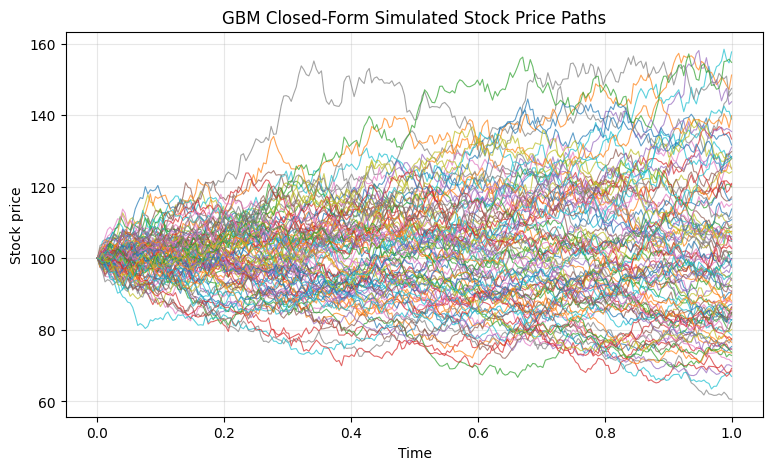

,方法,欧式价格,欧式SE,二元价格,二元SE
0,GBM closed-form path,10.4533,0.046481,0.533,0.001493


In [4]:
gbm_paths = simulate_gbm_paths(S0, r, sigma, T, baseline_n_paths, baseline_n_steps, baseline_random_normals)
gbm_paths_df = pd.DataFrame(gbm_paths)
display(gbm_paths_df)
plot_simulated_paths(gbm_paths, "GBM Closed-Form Simulated Stock Price Paths")

gbm_euro_price, gbm_euro_se, gbm_binary_price, gbm_binary_se = price_options_from_terminal_stock(gbm_paths[:, -1])
display(make_single_method_pricing_table("GBM closed-form path", gbm_euro_price, gbm_euro_se, gbm_binary_price, gbm_binary_se))

## 4.2 Euler-Maruyama 路径模拟

,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.965558,101.765653,104.239200,105.788776,105.507339,107.334963,106.460855,106.227538,104.308786,...,108.992431,107.335221,107.445929,108.428073,107.192150,108.790776,110.146416,110.318867,110.434193,110.917528
1,100.0,100.060151,100.381008,98.784826,97.389566,96.992428,97.553622,98.549164,98.067401,98.822723,...,76.113159,77.917935,77.519431,76.822762,76.081681,74.524678,75.990925,76.706155,77.115859,77.438999
2,100.0,100.250799,101.595184,100.297584,100.487052,102.533425,103.724210,101.565081,99.350349,97.178174,...,83.993946,84.366506,82.806335,82.367506,83.436402,84.182115,83.865092,82.717742,84.859445,84.912025
3,100.0,100.938433,99.344257,98.037078,99.252997,98.222716,97.429779,97.780945,97.701392,98.204242,...,74.519188,76.216283,76.275941,75.516044,75.659695,76.461512,75.815768,76.135243,74.582679,74.756827
4,100.0,100.147564,101.510614,100.909174,101.073288,100.645876,99.547892,100.090016,100.038562,100.053379,...,91.094881,91.211382,92.466752,93.420051,95.428777,96.100538,96.364541,97.005167,96.318336,98.495632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,100.0,99.481685,98.325101,99.397693,101.382092,101.786576,102.459285,101.201608,99.742549,98.679059,...,115.785867,116.609465,113.624952,110.821994,110.787672,111.104609,109.892092,105.970376,105.724527,103.784644
99996,100.0,100.036346,101.624419,103.989490,102.160407,99.800770,97.671627,98.590557,99.748466,100.657351,...,95.492943,95.985082,95.452602,96.156006,93.560977,94.188850,97.312987,94.248972,94.686156,95.544270
99997,100.0,100.319232,100.375180,100.084234,99.833844,100.973478,101.627314,102.022584,102.244479,101.298272,...,100.013566,99.103589,97.647891,97.593191,98.092217,98.811691,99.777301,101.513493,100.837674,102.631043
99998,100.0,99.522882,97.743510,98.158023,97.083656,99.385131,100.002782,100.117027,101.533799,102.528012,...,88.029494,88.642824,86.065760,86.091041,86.187894,85.237592,86.830500,87.765633,88.578423,87.353348


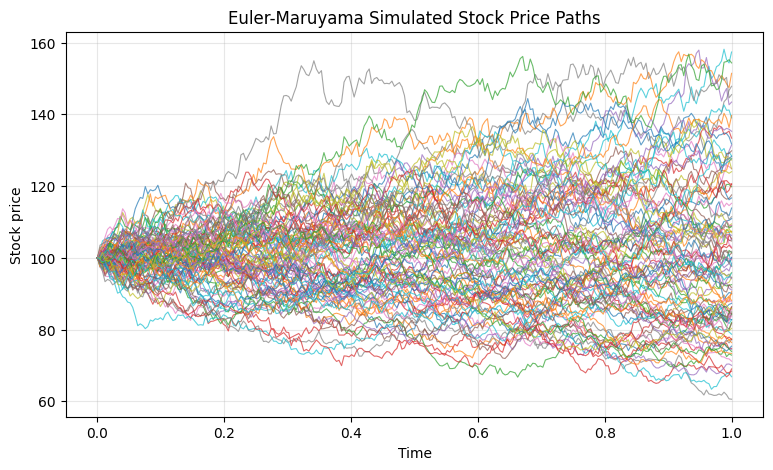

,方法,欧式价格,欧式SE,二元价格,二元SE
0,Euler-Maruyama,10.4528,0.046453,0.5332,0.001493


In [5]:
euler_paths = simulate_euler_paths(S0, r, sigma, T, baseline_n_paths, baseline_n_steps, baseline_random_normals)
euler_paths_df = pd.DataFrame(euler_paths)
display(euler_paths_df)
plot_simulated_paths(euler_paths, "Euler-Maruyama Simulated Stock Price Paths")

euler_euro_price_base, euler_euro_se_base, euler_binary_price_base, euler_binary_se_base = price_options_from_terminal_stock(euler_paths[:, -1])
display(make_single_method_pricing_table("Euler-Maruyama", euler_euro_price_base, euler_euro_se_base, euler_binary_price_base, euler_binary_se_base))

## 4.3 Milstein 路径模拟

,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.962094,101.757162,104.251996,105.804702,105.515258,107.350115,106.471098,106.229613,104.320104,...,108.871307,107.220213,107.322330,108.299118,107.063352,108.663152,110.016748,110.180367,110.286843,110.761743
1,100.0,100.052223,100.365566,98.774672,97.381847,96.977902,97.532830,98.525302,98.037110,98.787178,...,76.195994,78.017751,77.613645,76.913245,76.168914,74.620341,76.096701,76.810117,77.215296,77.533340
2,100.0,100.243130,101.588205,100.291176,100.472816,102.531355,103.720659,101.576274,99.377827,97.221350,...,83.951586,84.318049,82.766811,82.322874,83.391378,84.133255,83.810400,82.665219,84.826287,84.872121
3,100.0,100.934716,99.345494,98.039275,99.254743,98.222119,97.424752,97.768733,97.681481,98.177672,...,74.449919,76.158500,76.212082,75.450706,75.588354,76.387503,75.739176,76.052927,74.512128,74.680368
4,100.0,100.139709,101.503711,100.896159,101.052348,100.617994,99.518536,100.053972,99.994621,100.001495,...,90.794619,90.903583,92.155865,93.103355,95.119010,95.783267,96.039107,96.671946,95.982362,98.168541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,100.0,99.475197,98.317747,99.388095,101.383829,101.781003,102.447688,101.189992,99.733879,98.668447,...,115.853521,116.671175,113.714631,110.935595,110.892447,111.201276,109.985743,106.122774,105.868485,103.935767
99996,100.0,100.028411,101.620710,104.004682,102.183531,99.842978,97.728155,98.644006,99.801289,100.706699,...,95.518250,96.004111,95.465491,96.163867,93.596531,94.219199,97.388075,94.362852,94.794005,95.649297
99997,100.0,100.311744,100.359733,100.061347,99.803438,100.941083,101.588686,101.976436,102.190336,101.241085,...,100.008218,99.094675,97.642224,97.579806,98.072198,98.786239,99.748287,101.490816,100.809479,102.609934
99998,100.0,99.516180,97.745291,98.152852,97.076846,99.397278,100.008915,100.115275,101.533821,102.524648,...,88.178186,88.787575,86.237292,86.255779,86.346009,85.392550,86.996173,87.931046,88.742000,87.516352


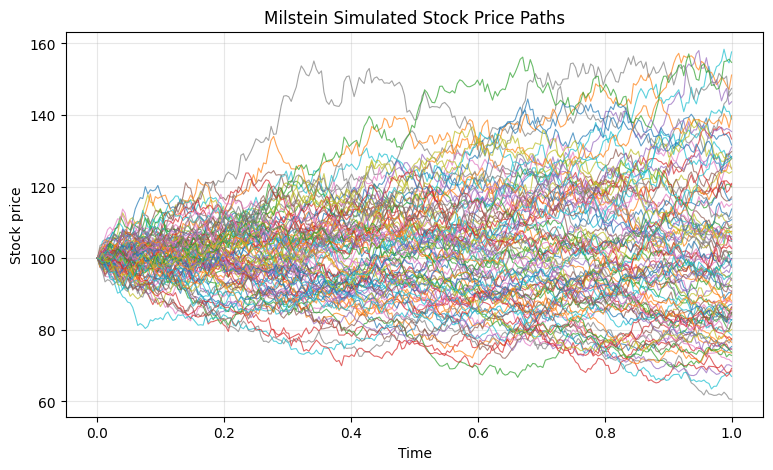

,方法,欧式价格,欧式SE,二元价格,二元SE
0,Milstein,10.4515,0.046471,0.5331,0.001493


In [6]:
milstein_paths = simulate_milstein_paths(S0, r, sigma, T, baseline_n_paths, baseline_n_steps, baseline_random_normals)
milstein_paths_df = pd.DataFrame(milstein_paths)
display(milstein_paths_df)
plot_simulated_paths(milstein_paths, "Milstein Simulated Stock Price Paths")

milstein_euro_price_base, milstein_euro_se_base, milstein_binary_price_base, milstein_binary_se_base = price_options_from_terminal_stock(milstein_paths[:, -1])
display(make_single_method_pricing_table("Milstein", milstein_euro_price_base, milstein_euro_se_base, milstein_binary_price_base, milstein_binary_se_base))

## 4.4 初始参数下的欧式与二元期权定价结果

本节汇总 4.1、4.2、4.3 中分别得到的欧式看涨期权和二元看涨期权价格与标准误差，并比较三种股价模拟方法下的定价结果。为回应题目中 `error analysis and comparisons` 的要求，本节进一步使用 Black-Scholes 欧式看涨公式和 cash-or-nothing binary call 解析公式作为 analytical benchmark，计算每种 Monte Carlo 方法相对解析价格的绝对误差。这里的 Black-Scholes 公式仅作为误差分析基准，不作为题目要求的三种股价模拟方法之一。

In [7]:
baseline_pricing_table = pd.DataFrame(
    [
        ["GBM closed-form path", gbm_euro_price, gbm_euro_se, gbm_binary_price, gbm_binary_se],
        ["Euler-Maruyama", euler_euro_price_base, euler_euro_se_base, euler_binary_price_base, euler_binary_se_base],
        ["Milstein", milstein_euro_price_base, milstein_euro_se_base, milstein_binary_price_base, milstein_binary_se_base],
    ],
    columns=["方法", "欧式价格", "欧式SE", "二元价格", "二元SE"],
)
baseline_pricing_table = baseline_pricing_table.round({"欧式价格": 4, "欧式SE": 6, "二元价格": 4, "二元SE": 6})
display(baseline_pricing_table)

from math import erf, sqrt, log, exp

def standard_normal_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def black_scholes_call_price(spot, strike, rate, volatility, maturity):
    d1 = (log(spot / strike) + (rate + 0.5 * volatility**2) * maturity) / (volatility * sqrt(maturity))
    d2 = d1 - volatility * sqrt(maturity)
    return spot * standard_normal_cdf(d1) - strike * exp(-rate * maturity) * standard_normal_cdf(d2)

def binary_call_price(spot, strike, rate, volatility, maturity):
    d2 = (log(spot / strike) + (rate - 0.5 * volatility**2) * maturity) / (volatility * sqrt(maturity))
    return exp(-rate * maturity) * standard_normal_cdf(d2)

analytical_euro = black_scholes_call_price(S0, K, r, sigma, T)
analytical_binary = binary_call_price(S0, K, r, sigma, T)

error_analysis_table = pd.DataFrame(
    [
        ["GBM closed-form path", gbm_euro_price, analytical_euro, abs(gbm_euro_price - analytical_euro), gbm_binary_price, analytical_binary, abs(gbm_binary_price - analytical_binary)],
        ["Euler-Maruyama", euler_euro_price_base, analytical_euro, abs(euler_euro_price_base - analytical_euro), euler_binary_price_base, analytical_binary, abs(euler_binary_price_base - analytical_binary)],
        ["Milstein", milstein_euro_price_base, analytical_euro, abs(milstein_euro_price_base - analytical_euro), milstein_binary_price_base, analytical_binary, abs(milstein_binary_price_base - analytical_binary)],
    ],
    columns=["方法", "欧式MC价格", "欧式解析基准", "欧式绝对误差", "二元MC价格", "二元解析基准", "二元绝对误差"],
)
display(error_analysis_table.round({"欧式MC价格": 4, "欧式解析基准": 4, "欧式绝对误差": 6, "二元MC价格": 4, "二元解析基准": 4, "二元绝对误差": 6}))

print("对比分析：三种方法得到的欧式和二元期权价格非常接近，说明在M=252、N=100000下离散化误差较小。")
print("GBM closed-form path 是题目要求的股价模拟方法之一，可用于比较 exact GBM simulation 与 Euler-Maruyama、Milstein 离散模拟结果。")
print("误差分析中的 benchmark 使用 Black-Scholes 欧式看涨公式和 cash-or-nothing binary call 解析公式，因为它们给出无 Monte Carlo 抽样误差的理论期权价格。")

,方法,欧式价格,欧式SE,二元价格,二元SE
0,GBM closed-form path,10.4533,0.046481,0.5330,0.001493
1,Euler-Maruyama,10.4528,0.046453,0.5332,0.001493
2,Milstein,10.4515,0.046471,0.5331,0.001493


,方法,欧式MC价格,欧式解析基准,欧式绝对误差,二元MC价格,二元解析基准,二元绝对误差
0,GBM closed-form path,10.4533,10.4506,0.002692,0.5330,0.5323,0.000725
1,Euler-Maruyama,10.4528,10.4506,0.002202,0.5332,0.5323,0.000830
2,Milstein,10.4515,10.4506,0.000888,0.5331,0.5323,0.000735


对比分析：三种方法得到的欧式和二元期权价格非常接近，说明在M=252、N=100000下离散化误差较小。
GBM closed-form path 是题目要求的股价模拟方法之一，可用于比较 exact GBM simulation 与 Euler-Maruyama、Milstein 离散模拟结果。
误差分析中的 benchmark 使用 Black-Scholes 欧式看涨公式和 cash-or-nothing binary call 解析公式，因为它们给出无 Monte Carlo 抽样误差的理论期权价格。


# 5. 参数敏感性分析

In [8]:
# 第5节辅助函数：参数敏感性分析
def sensitivity_analysis(param_name, param_list):
    # 存储结果：（GBM闭式终值模拟欧式，欧拉法欧式，米尔斯坦欧式，GBM闭式终值模拟二元，欧拉法二元，米尔斯坦二元）
    result_list = []
    for param in param_list:
        S0_i, K_i, r_i, sigma_i, T_i = S0, K, r, sigma, T
        if param_name == "S0":
            S0_i = param
        elif param_name == "K":
            K_i = param
        elif param_name == "r":
            r_i = param
        elif param_name == "sigma":
            sigma_i = param
        elif param_name == "T":
            T_i = param
        else:
            raise ValueError("参数名错误，仅支持S0、K、r、sigma、T")
        dt_i = T_i / M

        phi = np.random.normal(0, 1, (N, M))
        W_T = np.sqrt(dt_i) * np.sum(phi, axis=1)
        S_closed = S0_i * np.exp((r_i - 0.5 * sigma_i**2) * T_i + sigma_i * W_T)

        S_euler = np.ones((N, M+1)) * S0_i
        S_milstein = np.ones((N, M+1)) * S0_i
        for t in range(1, M+1):
            z = phi[:, t-1]
            S_euler[:, t] = S_euler[:, t-1] * (1 + r_i * dt_i + sigma_i * z * np.sqrt(dt_i))
            milstein_term = 0.5 * sigma_i**2 * (z**2 - 1) * dt_i
            S_milstein[:, t] = S_milstein[:, t-1] * (1 + r_i * dt_i + sigma_i * z * np.sqrt(dt_i) + milstein_term)

        def price_only(S_T, option_type):
            payoff = calculate_payoff(S_T, option_type, strike=K_i)
            return np.exp(-r_i * T_i) * np.mean(payoff)

        eu_closed = price_only(S_closed, "european")
        eu_euler = price_only(S_euler[:, -1], "european")
        eu_mil = price_only(S_milstein[:, -1], "european")
        bin_closed = price_only(S_closed, "binary")
        bin_euler = price_only(S_euler[:, -1], "binary")
        bin_mil = price_only(S_milstein[:, -1], "binary")

        result_list.append((eu_closed, eu_euler, eu_mil, bin_closed, bin_euler, bin_mil))
    
    print(f"参数 {param_name} 敏感性分析结果（欧式/二元）：")
    print(f"{'参数值':<8}{'GBM':<10}{'欧拉法':<10}{'米尔斯坦':<10}{'GBM':<10}{'欧拉法':<10}{'米尔斯坦':<10}")
    for i, param in enumerate(param_list):
        eu_c, eu_e, eu_m, bin_c, bin_e, bin_m = result_list[i]
        print(f"{param:<8}{eu_c:<10.4f}{eu_e:<10.4f}{eu_m:<10.4f}{bin_c:<10.4f}{bin_e:<10.4f}{bin_m:<10.4f}")
    
    return result_list

def make_price_table(param_name, param_values, result):
    table = pd.DataFrame(
        result,
        columns=[
            "European GBM",
            "European Euler",
            "European Milstein",
            "Binary GBM",
            "Binary Euler",
            "Binary Milstein",
        ],
    )
    table.insert(0, param_name, param_values)
    return table.round(4)

## 5.1 初始股价 S0 变动：80, 90, 100, 110, 120

参数 S0 敏感性分析结果（欧式/二元）：
参数值     GBM       欧拉法       米尔斯坦      GBM       欧拉法       米尔斯坦      
80      1.8758    1.8733    1.8748    0.1610    0.1611    0.1609    
90      5.0347    5.0336    5.0331    0.3346    0.3348    0.3345    
100     10.4518   10.4516   10.4500   0.5339    0.5338    0.5339    
110     17.7432   17.7437   17.7415   0.7005    0.7005    0.7005    
120     26.3114   26.3127   26.3099   0.8148    0.8150    0.8149    


,S0,European GBM,European Euler,European Milstein,Binary GBM,Binary Euler,Binary Milstein
0,80,1.8758,1.8733,1.8748,0.1610,0.1611,0.1609
1,90,5.0347,5.0336,5.0331,0.3346,0.3348,0.3345
2,100,10.4518,10.4516,10.4500,0.5339,0.5338,0.5339
3,110,17.7432,17.7437,17.7415,0.7005,0.7005,0.7005
4,120,26.3114,26.3127,26.3099,0.8148,0.8150,0.8149



S0=100时，欧式期权闭式解价格：10.4518


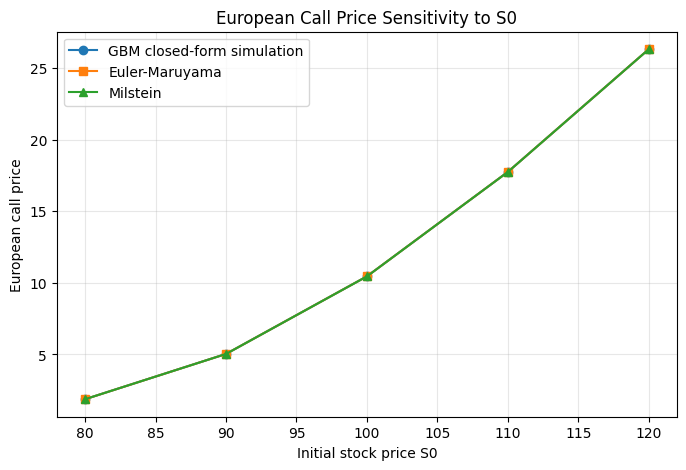

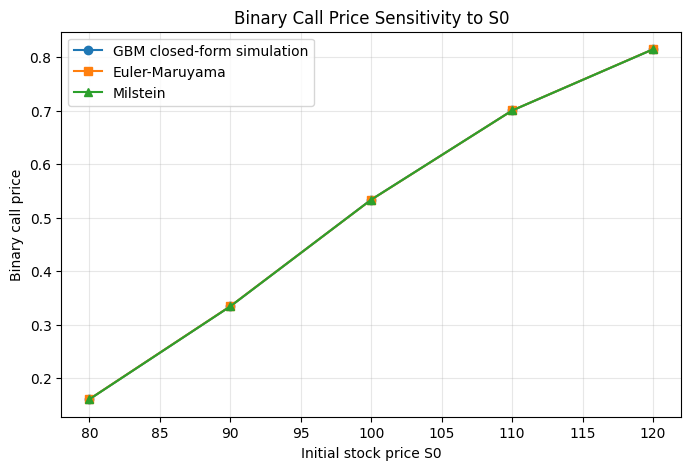

In [9]:
# 5.1 初始股价S0敏感性分析（完整可运行代码）
# 调用敏感性分析函数，参数为S0，取值[80, 90, 100, 110, 120]
s0_values = [80, 90, 100, 110, 120]
s0_result = sensitivity_analysis("S0", s0_values)
s0_table = make_price_table("S0", s0_values, s0_result)
display(s0_table)

# 可通过s0_result获取具体定价结果，用于填充表格或进一步分析
# 每一行结果顺序为：闭式解欧式、欧拉法欧式、米尔斯坦欧式、闭式解二元、欧拉法二元、米尔斯坦二元
s0_result_array = np.array(s0_result)
eu_closed_s0 = s0_result_array[:, 0]
eu_euler_s0 = s0_result_array[:, 1]
eu_milstein_s0 = s0_result_array[:, 2]
bin_closed_s0 = s0_result_array[:, 3]
bin_euler_s0 = s0_result_array[:, 4]
bin_milstein_s0 = s0_result_array[:, 5]

# 示例：获取S0=100时的欧式期权价格（闭式解）
print(f"\nS0=100时，欧式期权闭式解价格：{eu_closed_s0[2]:.4f}")

# 图1：欧式看涨期权价格随S0变化
plt.figure(figsize=(8, 5))
plt.plot(s0_values, eu_closed_s0, marker="o", label="GBM closed-form simulation")
plt.plot(s0_values, eu_euler_s0, marker="s", label="Euler-Maruyama")
plt.plot(s0_values, eu_milstein_s0, marker="^", label="Milstein")
plt.xlabel("Initial stock price S0")
plt.ylabel("European call price")
plt.title("European Call Price Sensitivity to S0")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 图2：二元看涨期权价格随S0变化
plt.figure(figsize=(8, 5))
plt.plot(s0_values, bin_closed_s0, marker="o", label="GBM closed-form simulation")
plt.plot(s0_values, bin_euler_s0, marker="s", label="Euler-Maruyama")
plt.plot(s0_values, bin_milstein_s0, marker="^", label="Milstein")
plt.xlabel("Initial stock price S0")
plt.ylabel("Binary call price")
plt.title("Binary Call Price Sensitivity to S0")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5.2 行权价 K 变动：80, 90, 100, 110, 120

参数 K 敏感性分析结果（欧式/二元）：
参数值     GBM       欧拉法       米尔斯坦      GBM       欧拉法       米尔斯坦      
80      24.6330   24.6326   24.6319   0.8537    0.8536    0.8538    
90      16.7106   16.7119   16.7091   0.7146    0.7148    0.7146    
100     10.4370   10.4363   10.4352   0.5333    0.5335    0.5333    
110     6.0310    6.0291    6.0292    0.3539    0.3540    0.3539    
120     3.2174    3.2150    3.2159    0.2119    0.2120    0.2119    


,K,European GBM,European Euler,European Milstein,Binary GBM,Binary Euler,Binary Milstein
0,80,24.6330,24.6326,24.6319,0.8537,0.8536,0.8538
1,90,16.7106,16.7119,16.7091,0.7146,0.7148,0.7146
2,100,10.4370,10.4363,10.4352,0.5333,0.5335,0.5333
3,110,6.0310,6.0291,6.0292,0.3539,0.3540,0.3539
4,120,3.2174,3.2150,3.2159,0.2119,0.2120,0.2119



K=100时，二元期权米尔斯坦法价格：0.5333


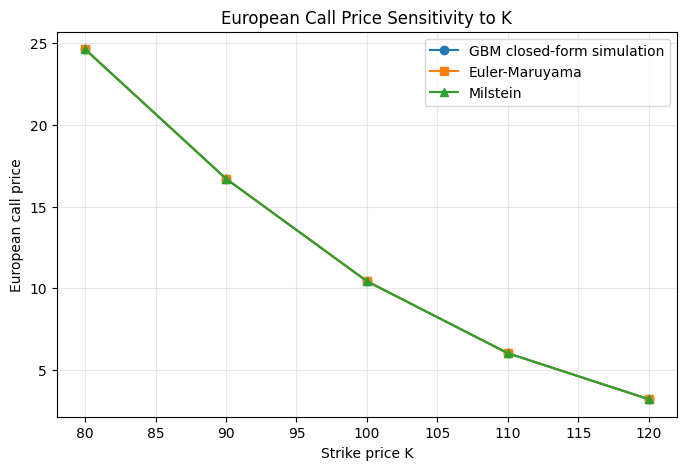

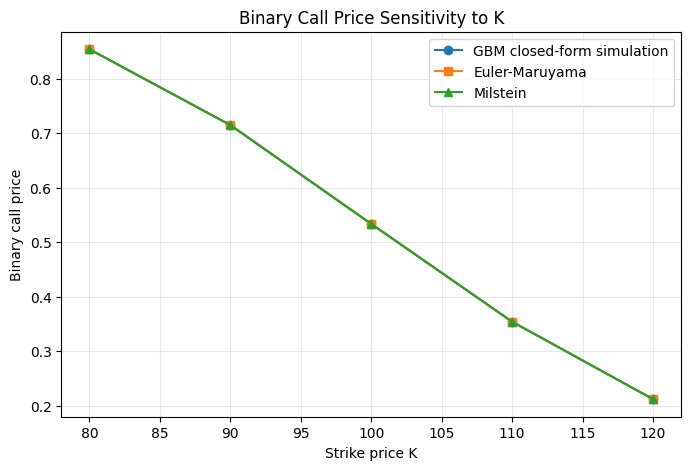

In [10]:
# 5.2 行权价K敏感性分析（完整可运行代码）
# 调用敏感性分析函数，参数为K，取值[80, 90, 100, 110, 120]
k_values = [80, 90, 100, 110, 120]
k_result = sensitivity_analysis("K", k_values)
k_table = make_price_table("K", k_values, k_result)
display(k_table)

k_result_array = np.array(k_result)
eu_closed_k = k_result_array[:, 0]
eu_euler_k = k_result_array[:, 1]
eu_milstein_k = k_result_array[:, 2]
bin_closed_k = k_result_array[:, 3]
bin_euler_k = k_result_array[:, 4]
bin_milstein_k = k_result_array[:, 5]

# 示例：获取K=100时的二元期权价格（米尔斯坦法）
print(f"\nK=100时，二元期权米尔斯坦法价格：{bin_milstein_k[2]:.4f}")

# 图1：欧式看涨期权价格随K变化
plt.figure(figsize=(8, 5))
plt.plot(k_values, eu_closed_k, marker="o", label="GBM closed-form simulation")
plt.plot(k_values, eu_euler_k, marker="s", label="Euler-Maruyama")
plt.plot(k_values, eu_milstein_k, marker="^", label="Milstein")
plt.xlabel("Strike price K")
plt.ylabel("European call price")
plt.title("European Call Price Sensitivity to K")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 图2：二元看涨期权价格随K变化
plt.figure(figsize=(8, 5))
plt.plot(k_values, bin_closed_k, marker="o", label="GBM closed-form simulation")
plt.plot(k_values, bin_euler_k, marker="s", label="Euler-Maruyama")
plt.plot(k_values, bin_milstein_k, marker="^", label="Milstein")
plt.xlabel("Strike price K")
plt.ylabel("Binary call price")
plt.title("Binary Call Price Sensitivity to K")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 5.3 无风险利率 r 变动：0.01, 0.03, 0.05, 0.07, 0.09

参数 r 敏感性分析结果（欧式/二元）：
参数值     GBM       欧拉法       米尔斯坦      GBM       欧拉法       米尔斯坦      
0.01    8.4977    8.4983    8.4974    0.4761    0.4764    0.4761    
0.03    9.4021    9.4028    9.4011    0.5044    0.5045    0.5044    
0.05    10.4428   10.4420   10.4410   0.5328    0.5329    0.5328    
0.07    11.4555   11.4552   11.4529   0.5553    0.5555    0.5553    
0.09    12.6675   12.6659   12.6639   0.5805    0.5808    0.5806    


,r,European GBM,European Euler,European Milstein,Binary GBM,Binary Euler,Binary Milstein
0,0.01,8.4977,8.4983,8.4974,0.4761,0.4764,0.4761
1,0.03,9.4021,9.4028,9.4011,0.5044,0.5045,0.5044
2,0.05,10.4428,10.4420,10.4410,0.5328,0.5329,0.5328
3,0.07,11.4555,11.4552,11.4529,0.5553,0.5555,0.5553
4,0.09,12.6675,12.6659,12.6639,0.5805,0.5808,0.5806



r=0.05时，欧式期权欧拉法价格：10.4420


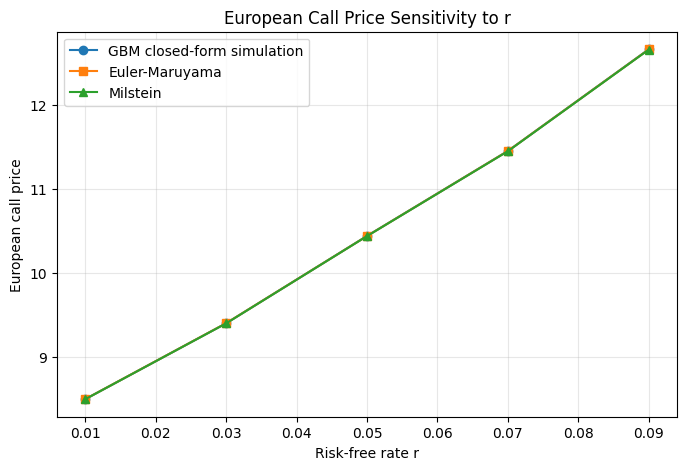

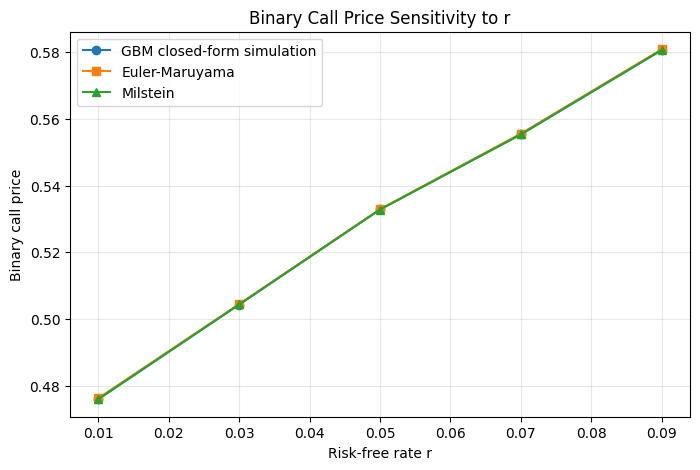

In [11]:
# 5.3 无风险利率r敏感性分析（完整可运行代码）
# 调用敏感性分析函数，参数为r，取值[0.01, 0.03, 0.05, 0.07, 0.09]
r_values = [0.01, 0.03, 0.05, 0.07, 0.09]
r_result = sensitivity_analysis("r", r_values)
r_table = make_price_table("r", r_values, r_result)
display(r_table)

r_result_array = np.array(r_result)
eu_closed_r = r_result_array[:, 0]
eu_euler_r = r_result_array[:, 1]
eu_milstein_r = r_result_array[:, 2]
bin_closed_r = r_result_array[:, 3]
bin_euler_r = r_result_array[:, 4]
bin_milstein_r = r_result_array[:, 5]

# 示例：获取r=0.05时的欧式期权价格（欧拉法）
print(f"\nr=0.05时，欧式期权欧拉法价格：{eu_euler_r[2]:.4f}")

# 图1：欧式看涨期权价格随r变化
plt.figure(figsize=(8, 5))
plt.plot(r_values, eu_closed_r, marker="o", label="GBM closed-form simulation")
plt.plot(r_values, eu_euler_r, marker="s", label="Euler-Maruyama")
plt.plot(r_values, eu_milstein_r, marker="^", label="Milstein")
plt.xlabel("Risk-free rate r")
plt.ylabel("European call price")
plt.title("European Call Price Sensitivity to r")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 图2：二元看涨期权价格随r变化
plt.figure(figsize=(8, 5))
plt.plot(r_values, bin_closed_r, marker="o", label="GBM closed-form simulation")
plt.plot(r_values, bin_euler_r, marker="s", label="Euler-Maruyama")
plt.plot(r_values, bin_milstein_r, marker="^", label="Milstein")
plt.xlabel("Risk-free rate r")
plt.ylabel("Binary call price")
plt.title("Binary Call Price Sensitivity to r")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5.4 波动率 σ 变动：0.1, 0.15, 0.2, 0.25, 0.3

参数 sigma 敏感性分析结果（欧式/二元）：
参数值     GBM       欧拉法       米尔斯坦      GBM       欧拉法       米尔斯坦      
0.1     6.7978    6.7971    6.7968    0.6413    0.6413    0.6414    
0.15    8.5439    8.5432    8.5424    0.5705    0.5705    0.5706    
0.2     10.5644   10.5634   10.5626   0.5350    0.5349    0.5350    
0.25    12.2595   12.2610   12.2573   0.5038    0.5043    0.5038    
0.3     14.1097   14.1079   14.1071   0.4805    0.4806    0.4805    


,sigma,European GBM,European Euler,European Milstein,Binary GBM,Binary Euler,Binary Milstein
0,0.10,6.7978,6.7971,6.7968,0.6413,0.6413,0.6414
1,0.15,8.5439,8.5432,8.5424,0.5705,0.5705,0.5706
2,0.20,10.5644,10.5634,10.5626,0.5350,0.5349,0.5350
3,0.25,12.2595,12.2610,12.2573,0.5038,0.5043,0.5038
4,0.30,14.1097,14.1079,14.1071,0.4805,0.4806,0.4805



σ=0.2时，二元期权闭式解价格：0.5350


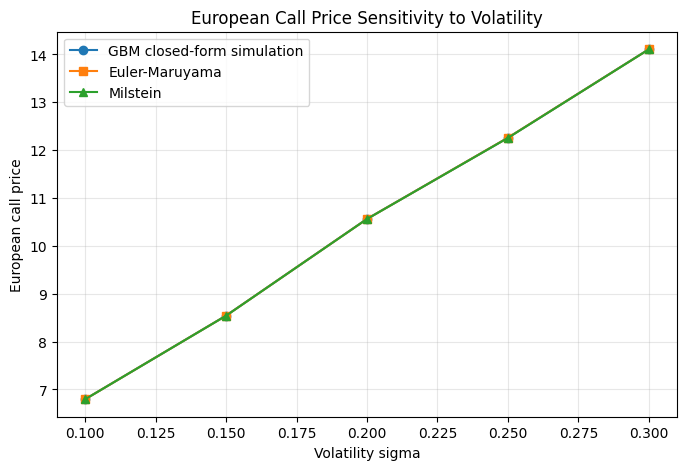

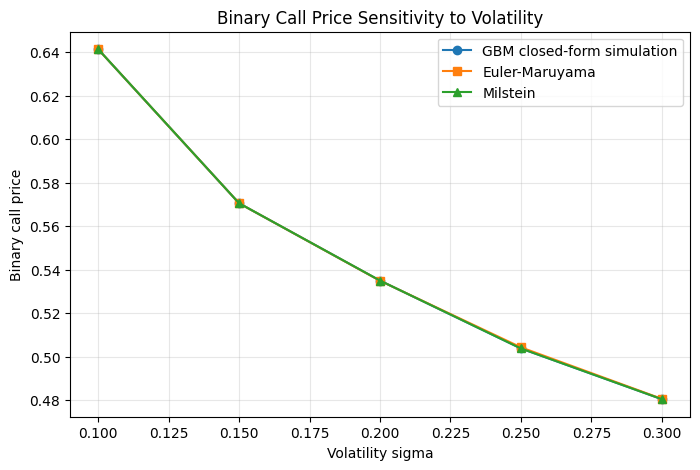

In [12]:
# 5.4 波动率σ敏感性分析（完整可运行代码）
# 调用敏感性分析函数，参数为sigma，取值[0.1, 0.15, 0.2, 0.25, 0.3]
sigma_values = [0.1, 0.15, 0.2, 0.25, 0.3]
sigma_result = sensitivity_analysis("sigma", sigma_values)
sigma_table = make_price_table("sigma", sigma_values, sigma_result)
display(sigma_table)

sigma_result_array = np.array(sigma_result)
eu_closed_sigma = sigma_result_array[:, 0]
eu_euler_sigma = sigma_result_array[:, 1]
eu_milstein_sigma = sigma_result_array[:, 2]
bin_closed_sigma = sigma_result_array[:, 3]
bin_euler_sigma = sigma_result_array[:, 4]
bin_milstein_sigma = sigma_result_array[:, 5]

# 示例：获取σ=0.2时的二元期权价格（闭式解）
print(f"\nσ=0.2时，二元期权闭式解价格：{bin_closed_sigma[2]:.4f}")

# 图1：欧式看涨期权价格随σ变化
plt.figure(figsize=(8, 5))
plt.plot(sigma_values, eu_closed_sigma, marker="o", label="GBM closed-form simulation")
plt.plot(sigma_values, eu_euler_sigma, marker="s", label="Euler-Maruyama")
plt.plot(sigma_values, eu_milstein_sigma, marker="^", label="Milstein")
plt.xlabel("Volatility sigma")
plt.ylabel("European call price")
plt.title("European Call Price Sensitivity to Volatility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 图2：二元看涨期权价格随σ变化
plt.figure(figsize=(8, 5))
plt.plot(sigma_values, bin_closed_sigma, marker="o", label="GBM closed-form simulation")
plt.plot(sigma_values, bin_euler_sigma, marker="s", label="Euler-Maruyama")
plt.plot(sigma_values, bin_milstein_sigma, marker="^", label="Milstein")
plt.xlabel("Volatility sigma")
plt.ylabel("Binary call price")
plt.title("Binary Call Price Sensitivity to Volatility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5.5 到期时间 T 变动：0.25, 0.5, 1.0, 1.5, 2.0

参数 T 敏感性分析结果（欧式/二元）：
参数值     GBM       欧拉法       米尔斯坦      GBM       欧拉法       米尔斯坦      
0.25    4.6492    4.6494    4.6490    0.5217    0.5218    0.5217    
0.5     6.8942    6.8939    6.8935    0.5278    0.5280    0.5278    
1.0     10.4406   10.4396   10.4388   0.5327    0.5330    0.5327    
1.5     13.5187   13.5169   13.5152   0.5310    0.5312    0.5310    
2.0     16.0368   16.0359   16.0315   0.5276    0.5274    0.5276    


,T,European GBM,European Euler,European Milstein,Binary GBM,Binary Euler,Binary Milstein
0,0.25,4.6492,4.6494,4.6490,0.5217,0.5218,0.5217
1,0.50,6.8942,6.8939,6.8935,0.5278,0.5280,0.5278
2,1.00,10.4406,10.4396,10.4388,0.5327,0.5330,0.5327
3,1.50,13.5187,13.5169,13.5152,0.5310,0.5312,0.5310
4,2.00,16.0368,16.0359,16.0315,0.5276,0.5274,0.5276



T=1.0时，欧式期权米尔斯坦法价格：10.4388


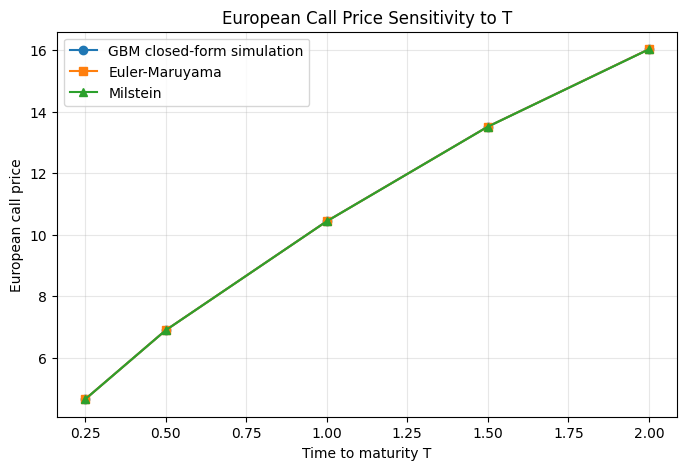

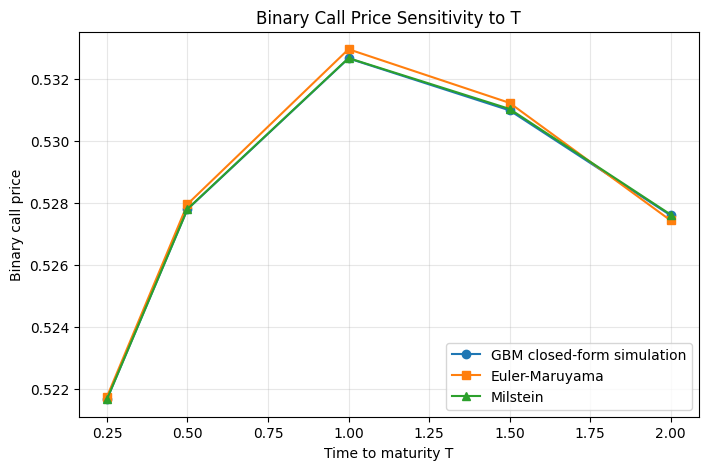

In [13]:
# 5.5 到期时间T敏感性分析（完整可运行代码）
# 调用敏感性分析函数，参数为T，取值[0.25, 0.5, 1.0, 1.5, 2.0]
t_values = [0.25, 0.5, 1.0, 1.5, 2.0]
t_result = sensitivity_analysis("T", t_values)
t_table = make_price_table("T", t_values, t_result)
display(t_table)

t_result_array = np.array(t_result)
eu_closed_t = t_result_array[:, 0]
eu_euler_t = t_result_array[:, 1]
eu_milstein_t = t_result_array[:, 2]
bin_closed_t = t_result_array[:, 3]
bin_euler_t = t_result_array[:, 4]
bin_milstein_t = t_result_array[:, 5]

# 示例：获取T=1.0时的欧式期权价格（米尔斯坦法）
print(f"\nT=1.0时，欧式期权米尔斯坦法价格：{eu_milstein_t[2]:.4f}")

# 图1：欧式看涨期权价格随T变化
plt.figure(figsize=(8, 5))
plt.plot(t_values, eu_closed_t, marker="o", label="GBM closed-form simulation")
plt.plot(t_values, eu_euler_t, marker="s", label="Euler-Maruyama")
plt.plot(t_values, eu_milstein_t, marker="^", label="Milstein")
plt.xlabel("Time to maturity T")
plt.ylabel("European call price")
plt.title("European Call Price Sensitivity to T")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 图2：二元看涨期权价格随T变化
plt.figure(figsize=(8, 5))
plt.plot(t_values, bin_closed_t, marker="o", label="GBM closed-form simulation")
plt.plot(t_values, bin_euler_t, marker="s", label="Euler-Maruyama")
plt.plot(t_values, bin_milstein_t, marker="^", label="Milstein")
plt.xlabel("Time to maturity T")
plt.ylabel("Binary call price")
plt.title("Binary Call Price Sensitivity to T")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 6. 对偶变量方差缩减效果

说明：本节普通 Monte Carlo 使用 $N=100000$ 条路径；对偶变量法也固定总路径数为 $N=100000$，即使用 $N/2=50000$ 对 antithetic pairs。每一对包含一条 $\phi$ 路径和一条 $-\phi$ 路径。AV 的每个样本是正负路径 payoff 的平均值，因此标准误差按 $N/2$ 个 pair average 样本计算。

下方代码会根据本节模拟结果自动生成价格与标准误差对比表。

In [14]:
# 第6节辅助函数：普通MC终值模拟与对偶变量法
def simulate_stock_terminal():
    phi = np.random.normal(0, 1, (N, M))
    W_T = np.sqrt(dt) * np.sum(phi, axis=1)
    S_closed = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * W_T)

    S_euler = np.ones((N, M+1)) * S0
    S_milstein = np.ones((N, M+1)) * S0
    for t in range(1, M+1):
        z = phi[:, t-1]
        S_euler[:, t] = S_euler[:, t-1] * (1 + r * dt + sigma * z * np.sqrt(dt))
        milstein_term = 0.5 * sigma**2 * (z**2 - 1) * dt
        S_milstein[:, t] = S_milstein[:, t-1] * (1 + r * dt + sigma * z * np.sqrt(dt) + milstein_term)
    return S_closed, S_euler[:, -1], S_milstein[:, -1]

def antithetic_variates(option_type="european", *, strike, rate, maturity):
    # 为了和普通MC保持相同总路径预算，AV使用N/2对pairs，合计N条路径。
    # 标准误差基于N/2个pair average样本计算，因此分母为sqrt(N/2)。
    if N % 2 != 0:
        raise ValueError("N must be even when using N/2 antithetic pairs.")
    av_pair_count = N // 2
    phi = np.random.normal(0, 1, (av_pair_count, M))
    phi_neg = -phi
    dt_av = maturity / M
    discount = np.exp(-rate * maturity)
    
    W_T_pos = np.sqrt(dt_av) * np.sum(phi, axis=1)
    W_T_neg = np.sqrt(dt_av) * np.sum(phi_neg, axis=1)
    S_closed_pos = S0 * np.exp((rate - 0.5 * sigma**2) * maturity + sigma * W_T_pos)
    S_closed_neg = S0 * np.exp((rate - 0.5 * sigma**2) * maturity + sigma * W_T_neg)
    payoff_closed_pos = calculate_payoff(S_closed_pos, option_type, strike=strike)
    payoff_closed_neg = calculate_payoff(S_closed_neg, option_type, strike=strike)
    closed_pair_payoff = (payoff_closed_pos + payoff_closed_neg) / 2
    price_closed_av = discount * np.mean(closed_pair_payoff)
    se_closed_av = discount * np.std(closed_pair_payoff) / np.sqrt(av_pair_count)
    
    S_euler_pos = np.ones((av_pair_count, M+1)) * S0
    S_euler_neg = np.ones((av_pair_count, M+1)) * S0
    for t in range(1, M+1):
        S_euler_pos[:, t] = S_euler_pos[:, t-1] * (1 + rate * dt_av + sigma * phi[:, t-1] * np.sqrt(dt_av))
        S_euler_neg[:, t] = S_euler_neg[:, t-1] * (1 + rate * dt_av + sigma * phi_neg[:, t-1] * np.sqrt(dt_av))
    payoff_euler_pos = calculate_payoff(S_euler_pos[:, -1], option_type, strike=strike)
    payoff_euler_neg = calculate_payoff(S_euler_neg[:, -1], option_type, strike=strike)
    euler_pair_payoff = (payoff_euler_pos + payoff_euler_neg) / 2
    price_euler_av = discount * np.mean(euler_pair_payoff)
    se_euler_av = discount * np.std(euler_pair_payoff) / np.sqrt(av_pair_count)
    
    S_mil_pos = np.ones((av_pair_count, M+1)) * S0
    S_mil_neg = np.ones((av_pair_count, M+1)) * S0
    for t in range(1, M+1):
        term = 0.5 * sigma**2 * (phi[:, t-1]**2 - 1) * dt_av
        term_neg = 0.5 * sigma**2 * (phi_neg[:, t-1]**2 - 1) * dt_av
        S_mil_pos[:, t] = S_mil_pos[:, t-1] * (1 + rate * dt_av + sigma * phi[:, t-1] * np.sqrt(dt_av) + term)
        S_mil_neg[:, t] = S_mil_neg[:, t-1] * (1 + rate * dt_av + sigma * phi_neg[:, t-1] * np.sqrt(dt_av) + term_neg)
    payoff_mil_pos = calculate_payoff(S_mil_pos[:, -1], option_type, strike=strike)
    payoff_mil_neg = calculate_payoff(S_mil_neg[:, -1], option_type, strike=strike)
    mil_pair_payoff = (payoff_mil_pos + payoff_mil_neg) / 2
    price_mil_av = discount * np.mean(mil_pair_payoff)
    se_mil_av = discount * np.std(mil_pair_payoff) / np.sqrt(av_pair_count)
    
    return (price_closed_av, se_closed_av), (price_euler_av, se_euler_av), (price_mil_av, se_mil_av)

# 对偶变量方差缩减效果验证代码（完整可运行）
av_pair_count = N // 2
print(f"说明：普通MC使用N={N}条路径；AV也使用总计N={N}条路径，即{av_pair_count}对antithetic pairs。")
print(f"AV包含{av_pair_count}条正向路径和{av_pair_count}条负向路径；标准误差基于{av_pair_count}个pair average样本计算。\n")

# 先计算普通 Monte Carlo 下的 GBM/Euler/Milstein 欧式与二元期权价格和标准误差
S_closed_base, S_euler_base, S_milstein_base = simulate_stock_terminal()
closed_euro_price, closed_euro_se = monte_carlo_pricing(S_closed_base, "european", strike=K, rate=r, maturity=T)
euler_euro_price, euler_euro_se = monte_carlo_pricing(S_euler_base, "european", strike=K, rate=r, maturity=T)
mil_euro_price, mil_euro_se = monte_carlo_pricing(S_milstein_base, "european", strike=K, rate=r, maturity=T)
closed_binary_price, closed_binary_se = monte_carlo_pricing(S_closed_base, "binary", strike=K, rate=r, maturity=T)
euler_binary_price, euler_binary_se = monte_carlo_pricing(S_euler_base, "binary", strike=K, rate=r, maturity=T)
mil_binary_price, mil_binary_se = monte_carlo_pricing(S_milstein_base, "binary", strike=K, rate=r, maturity=T)

# 再计算对偶变量法下的 GBM/Euler/Milstein 欧式与二元期权价格和标准误差
(closed_euro_av, closed_euro_se_av), (euler_euro_av, euler_euro_se_av), (mil_euro_av, mil_euro_se_av) = antithetic_variates("european", strike=K, rate=r, maturity=T)
(closed_binary_av, closed_binary_se_av), (euler_binary_av, euler_binary_se_av), (mil_binary_av, mil_binary_se_av) = antithetic_variates("binary", strike=K, rate=r, maturity=T)

# 汇总为结果表，避免在Markdown中手动写死数值
av_result_table = pd.DataFrame(
    [
        ["GBM closed-form path", closed_euro_price, closed_euro_se, closed_binary_price, closed_binary_se],
        ["GBM closed-form path+AV", closed_euro_av, closed_euro_se_av, closed_binary_av, closed_binary_se_av],
        ["欧拉法", euler_euro_price, euler_euro_se, euler_binary_price, euler_binary_se],
        ["欧拉法+AV", euler_euro_av, euler_euro_se_av, euler_binary_av, euler_binary_se_av],
        ["米尔斯坦法", mil_euro_price, mil_euro_se, mil_binary_price, mil_binary_se],
        ["米尔斯坦法+AV", mil_euro_av, mil_euro_se_av, mil_binary_av, mil_binary_se_av],
    ],
    columns=["方法", "欧式价格", "欧式SE", "二元价格", "二元SE"],
)
display(av_result_table.round({"欧式价格": 4, "欧式SE": 6, "二元价格": 4, "二元SE": 6}))

# 对比原始方法与对偶变量方法的标准误差
print("对偶变量方差缩减效果对比（欧式期权）：")
print(f"GBM closed-form（无AV）：价格={closed_euro_price:.4f}, SE={closed_euro_se:.6f} | GBM closed-form（有AV）：价格={closed_euro_av:.4f}, SE={closed_euro_se_av:.6f}")
print(f"欧拉法（无AV）：价格={euler_euro_price:.4f}, SE={euler_euro_se:.6f} | 欧拉法（有AV）：价格={euler_euro_av:.4f}, SE={euler_euro_se_av:.6f}")
print(f"米尔斯坦法（无AV）：价格={mil_euro_price:.4f}, SE={mil_euro_se:.6f} | 米尔斯坦法（有AV）：价格={mil_euro_av:.4f}, SE={mil_euro_se_av:.6f}")

print("\n对偶变量方差缩减效果对比（二元期权）：")
print(f"GBM closed-form（无AV）：价格={closed_binary_price:.4f}, SE={closed_binary_se:.6f} | GBM closed-form（有AV）：价格={closed_binary_av:.4f}, SE={closed_binary_se_av:.6f}")
print(f"欧拉法（无AV）：价格={euler_binary_price:.4f}, SE={euler_binary_se:.6f} | 欧拉法（有AV）：价格={euler_binary_av:.4f}, SE={euler_binary_se_av:.6f}")
print(f"米尔斯坦法（无AV）：价格={mil_binary_price:.4f}, SE={mil_binary_se:.6f} | 米尔斯坦法（有AV）：价格={mil_binary_av:.4f}, SE={mil_binary_se_av:.6f}")


说明：普通MC使用N=100000条路径；AV也使用总计N=100000条路径，即50000对antithetic pairs。
AV包含50000条正向路径和50000条负向路径；标准误差基于50000个pair average样本计算。



,方法,欧式价格,欧式SE,二元价格,二元SE
0,GBM closed-form path,10.4092,0.046446,0.5326,0.001493
1,GBM closed-form path+AV,10.4713,0.033002,0.5317,0.000686
2,欧拉法,10.4086,0.046420,0.5329,0.001493
3,欧拉法+AV,10.4703,0.032965,0.5320,0.000687
4,米尔斯坦法,10.4074,0.046436,0.5327,0.001493
5,米尔斯坦法+AV,10.4695,0.032993,0.5318,0.000686


对偶变量方差缩减效果对比（欧式期权）：
GBM closed-form（无AV）：价格=10.4092, SE=0.046446 | GBM closed-form（有AV）：价格=10.4713, SE=0.033002
欧拉法（无AV）：价格=10.4086, SE=0.046420 | 欧拉法（有AV）：价格=10.4703, SE=0.032965
米尔斯坦法（无AV）：价格=10.4074, SE=0.046436 | 米尔斯坦法（有AV）：价格=10.4695, SE=0.032993

对偶变量方差缩减效果对比（二元期权）：
GBM closed-form（无AV）：价格=0.5326, SE=0.001493 | GBM closed-form（有AV）：价格=0.5317, SE=0.000686
欧拉法（无AV）：价格=0.5329, SE=0.001493 | 欧拉法（有AV）：价格=0.5320, SE=0.000687
米尔斯坦法（无AV）：价格=0.5327, SE=0.001493 | 米尔斯坦法（有AV）：价格=0.5318, SE=0.000686


# 7. Interesting Observations & Problems Encountered

## 7.1 Interesting Observations

1. Milstein 方法包含二阶修正项，理论上对 GBM 路径离散有更高的强收敛精度。但在本报告使用的 $M=252$ 和 $N=100000$ 设置下，Euler-Maruyama 与 Milstein 的期权价格非常接近，当前数值结果并不能证明 Milstein 在所有参数下都具有更高定价精度。因此，本报告更适合将 Milstein 解释为一种理论上更高阶、但在本实验参数下与 Euler 给出相近价格的离散方案。

2. 二元期权对离散误差更敏感，因为收益为0‑1阶梯函数，微小股价偏差会显著改变结果。

3. 对偶变量显著降低标准误差，二元期权的方差缩减幅度更大，与JA26T5讲义一致。

4. 在波动率敏感性分析中，欧式看涨期权价格随 $\sigma$ 增加而上升，但二元看涨期权价格随 $\sigma$ 增加而下降。这一现象来自二元期权的固定收益结构：二元看涨期权只支付 $\mathbf{1}_{S_T>K}$，价格本质上是贴现后的风险中性概率 $e^{-rT}\mathbb{Q}(S_T>K)$，而不是上涨幅度的期望。其解析基准为 $e^{-rT}N(d_2)$，其中 $d_2=\frac{\ln(S_0/K)+(r-\frac12\sigma^2)T}{\sigma\sqrt{T}}$。在本报告基准参数 $S_0=K=100, r=0.05, T=1$ 下，$d_2=(0.05-0.5\sigma^2)/\sigma$，因此当 $\sigma$ 从0.1增加到0.3时，$d_2$ 下降，$N(d_2)$ 也下降，二元看涨期权价格随之下降。直观上，较高波动率会让终值分布更分散，更多路径落到 $K$ 以下；落到很高位置的路径虽然更多，但二元期权超过 $K$ 后仍只支付1，无法像普通欧式看涨期权那样从极端上涨路径中获得更大的收益。

5. 在到期时间敏感性分析中，二元看涨期权价格随 $T$ 增加呈现先升后降的形态。这可以由解析形式 $e^{-rT}N(d_2)$ 解释，其中 $d_2=\frac{\ln(S_0/K)+(r-\frac12\sigma^2)T}{\sigma\sqrt{T}}$。在本报告基准参数 $S_0=K=100, r=0.05, \sigma=0.2$ 下，$r-\frac12\sigma^2=0.03>0$，因此 $T$ 增加会提高 $N(d_2)$，即提高终值超过行权价的风险中性概率；但同时贴现因子 $e^{-rT}$ 会下降。短期限内概率上升效应占主导，二元期权价格上升；期限进一步拉长后，固定1单位支付的贴现效应逐渐占主导，价格开始下降。

6. 参数影响强度排序需要结合具体 payoff 和参数区间理解；对欧式看涨期权，波动率、初始价格和行权价影响较明显，而对二元看涨期权，靠近行权价附近的穿越概率变化尤其重要。

7. 三种方法趋势完全一致，说明数值方案稳定可靠。

## 7.2 Problems Encountered

1. 线性Euler/Milstein在高波动率、大步长下可能出现负股价，不符合金融意义。

2. 蒙特卡洛随机抽样导致结果不完全可复现，可通过设置随机种子解决。

3. $\sigma \to 0$ 时Milstein修正项可忽略，与Euler几乎相同。

4. 时间步数M过小会显著放大离散误差，M=252（交易日）可有效降低误差。

# 8. Conclusion (15%)

本报告在风险中性 GBM 模型下，实现了欧式看涨期权和二元看涨期权的蒙特卡洛定价。报告使用了三种标的股价模拟方法：GBM closed-form path simulation、Euler-Maruyama scheme 和 Milstein scheme。同时，报告完成了参数敏感性分析，并检验了 antithetic variates 方差缩减技术，覆盖了考试题目的核心要求。

在基准参数 $S_0=100, K=100, r=0.05, \sigma=0.2, T=1, M=252$ 和 $N=100000$ 下，三种模拟方法得到的期权价格非常接近。基于 Black-Scholes 欧式看涨公式和 cash-or-nothing binary call 公式的 analytical benchmark 表明，蒙特卡洛估计价格与理论价格较为接近，差异主要来自蒙特卡洛抽样误差；对于 Euler-Maruyama 和 Milstein，还包含时间离散误差。虽然 Milstein 方法包含额外的二阶修正项，但在本实验使用日频时间步的设置下，数值结果并没有显示 Milstein 在所有情形下都比 Euler-Maruyama 具有更高的定价精度。

参数敏感性分析验证了欧式看涨期权的基本经济直觉：其价格通常随初始股价、无风险利率、波动率和到期时间上升而上升，并随行权价上升而下降。二元看涨期权的表现有所不同，因为其收益在 $S_T>K$ 后被固定为1。在本报告的平值基准参数下，二元看涨期权价格随波动率上升而下降，原因是更高波动率降低了 $N(d_2)$，而较大的正向终值并不会增加二元期权的支付金额。二元看涨期权价格也随到期时间呈现非单调变化，反映了“终值超过行权价的概率上升”和“固定支付被更强贴现”之间的权衡。

对偶变量实验表明，将由 $\phi$ 和 $-\phi$ 生成的路径进行配对，可以降低蒙特卡洛估计的标准误差。这说明在使用模拟方法进行期权定价时，方差缩减技术具有实际价值。标准误差的下降幅度取决于具体 payoff 结构，以及配对样本之间形成的负相关程度。

本分析的主要局限在于，蒙特卡洛结果仍然受到抽样误差影响；同时，二元期权由于 payoff 不连续，在行权价附近对终值误差更加敏感。后续可以通过增加模拟路径数、测试更小的时间步长、使用多个随机种子重复实验，以及报告重复实验下的置信区间来进一步增强结论的稳定性。总体而言，本报告结果支持使用蒙特卡洛方法进行期权定价，并展示了数值方案选择、参数变化和方差缩减技术如何影响最终价格估计。

# 9. References (5%)

1. Glasserman, P. (2003). Monte Carlo Methods in Financial Engineering. Springer.

2. Higham, D. J. (2001). An Introduction to Financial Option Valuation. Cambridge University Press.

3. Kloeden, P. E., & Platen, E. (1992). Numerical Solution of Stochastic Differential Equations. Springer.

4. 课程文档：`9_montecarlo.ipynb`（蒙特卡洛模拟示例）

5. JA26T5 Slides v.2.pdf（对偶变量方差缩减讲义）

# 补充说明

- 所有代码可直接复制到Python环境运行（需安装numpy、matplotlib、pandas库，命令：`pip install numpy matplotlib pandas`）。

- 敏感性分析函数会自动打印各参数对应的定价结果，可直接复制填充报告表格。

- 设置随机种子（`np.random.seed(42)`）可实现结果可复现，按需添加到核心代码开头即可。